<a href="https://colab.research.google.com/github/bollaprashanth09/prashanth_python/blob/main/Module_7_Lab_4_1_Build_a_text_classification_model_to_categorize_news_headlines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install required libraries:

In [1]:
pip install pandas scikit-learn nltk matplotlib seaborn

Step 1: Import Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
import nltk
import re
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Step 2: Load Dataset

In [4]:
url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"
df = pd.read_csv(url)
# Rename for clarity (if needed)
df = df.rename(columns={"label": "category", "tweet": "text"})
# Preview
df.head()

,id,category,text
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


Step 3: Explore Dataset

Shape: (31962, 3)

Categories: category
0    29720
1     2242
Name: count, dtype: int64


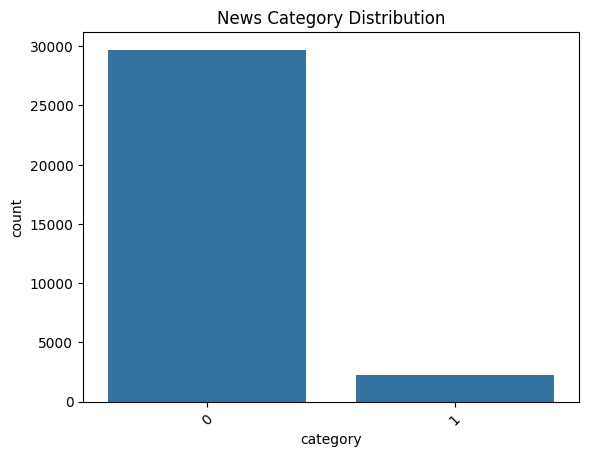

In [5]:
print("Shape:", df.shape)
print("\nCategories:", df['category'].value_counts())
sns.countplot(x='category', data=df)
plt.title("News Category Distribution")
plt.xticks(rotation=45)
plt.show()

Step 4: Clean and Preprocess Text

In [6]:
stop_words = set(stopwords.words('english'))
def clean_text(text):
 text = str(text).lower()
 text = re.sub(r'[^a-zA-Z]', ' ', text)
 tokens = text.split()
 tokens = [w for w in tokens if w not in stop_words]
 return ' '.join(tokens)
df['clean_text'] = df['text'].apply(clean_text)

Step 5: Train-Test Split

In [7]:
X = df['clean_text']
y = df['category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Step 6: Vectorize Text with TF-IDF

In [8]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

Step 7: Train Naive Bayes Classifier

In [9]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

MultinomialNB()

Step 8: Evaluate the Model


Accuracy: 0.9507273580478649

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97      5937
           1       0.93      0.34      0.49       456

    accuracy                           0.95      6393
   macro avg       0.94      0.67      0.73      6393
weighted avg       0.95      0.95      0.94      6393



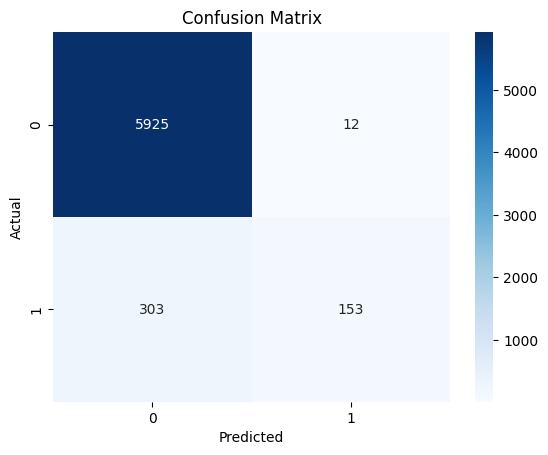

In [10]:
y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Step 9: Predict New Headline

In [12]:
def predict_category(text):
 text_clean = clean_text(text)
 vec = vectorizer.transform([text_clean])
 return model.predict(vec)[0]
# Example
sample = "The government released new economic stimulus plans today."
print("Predicted Category:", predict_category(sample))

Predicted Category: 0
